# Generalized Linear Models - catchments (NCA) -

Model to predict number of landslides in 651 catchments located in the northern Colombian Andes.

In [11]:
install.packages('ggExtra')

Installing package into 'C:/Users/edier/AppData/Local/R/win-library/4.3'
(as 'lib' is unspecified)



package 'ggExtra' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\edier\AppData\Local\Temp\Rtmpa4ImbS\downloaded_packages


In [10]:
library(brms)
library(tidyverse)
library(sjstats) #for calculating intra-class correlation (ICC)
library(effects) #for plotting parameter effects
library(mosaic)  # standardizing variables

library(lme4) #The package we use, lme4. An option is to use 'nlme'.
#library(plotly)#...and this one to generate interactive plots...
library(ggplot2)#...and this one to generate interactive plots...
library(ggExtra)#to adjust plots
library(bbmle) # to get delta AICs and BICs
library(sjPlot) # more plots... especially for coeffs for multilevel models...
library(lattice) #more plots
require(MuMIn) #To get Marginal and Conditional R2
require(AICcmodavg) #To get AICc
require(lmerTest) #To get the Satterthwaite- ...
require(pbkrtest) #... and Kenward-Roger approximations of p-values

ERROR: Error in library(ggExtra): there is no package called 'ggExtra'


In [2]:
df=read.csv("G:/My Drive/INVESTIGACION/POSDOC/GLM/df2.csv")

In [3]:
str(df)

'data.frame':	652 obs. of  17 variables:
 $ ID_CUENCA   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Nombre      : chr  "Quebrada Los San Andreses" "Quebrada Sabalito" "Quebrada El Perro" "Quebrada La Escondida" ...
 $ kmeans      : chr  "A" "A" "A" "A" ...
 $ geometry    : chr  "MULTIPOLYGON (((411860.43768 900002.54242, 411964.18528 899902.86942, 411926.11148 899852.69132, 411912.11008 8"| __truncated__ "MULTIPOLYGON (((505464.5759 881616.2717, 505673.2551 881608, 505688.4895 881640.3043, 505701.4777 881652.3283, "| __truncated__ "MULTIPOLYGON (((404379.05344 881850.76728, 404410.06544 881781.26808, 404463.26974 881739.60088, 404528.01584 8"| __truncated__ "MULTIPOLYGON (((425657.4836 874583.8163, 425619.5075 874595.8402, 425601.4777 874652.8043, 425569.8737 874712.5"| __truncated__ ...
 $ Área        : num  120.2 33.5 28.6 29 22.9 ...
 $ hypso_inte  : num  0.107 0.334 0.224 0.129 0.271 0.194 0.337 0.158 0.197 0.42 ...
 $ X_Ksmean    : num  6.2 2.19 18.83 3.94 1.45 ...
 $ X_chimean   : num  10.

In [4]:
df$lands_dens=df$lands_rec/df$Área

In [5]:
df <- df[-c(4)]

In [6]:
df <- cbind(df, set_names(lapply(df[5:12],\(x) (x - mean(x))/sd(x)),paste0(names(df[5:12]), '_Std')))

In [7]:
names(df)

[1] "ID_CUENCA"        "Nombre"           "kmeans"           "Área"            
 [5] "hypso_inte"       "X_Ksmean"         "X_chimean"        "rainfall_cat"    
 [9] "Densidad"         "elev_mean"        "slope_mean"       "rel_mean"        
[13] "cuenca"           "lands_rec"        "lands_rel"        "landslides"      
[17] "lands_dens"       "hypso_inte_Std"   "X_Ksmean_Std"     "X_chimean_Std"   
[21] "rainfall_cat_Std" "Densidad_Std"     "elev_mean_Std"    "slope_mean_Std"  
[25] "rel_mean_Std"

## GLM

### Intercept model
An intercept only model is the simplest form of HLM and recommended as the first step before adding any other predictive terms. This type of model testing allows us to understand whether the outcome variable scores (i.e., relationship satisfaction in this tutorial) are significantly different from zero (i.e., participants have indicated certain relationship satisfaction levels) without considering other predictors. For an OLS model, an intercept is also known as the constant, which in an intercept only model is the mean of the outcome variable, as shown in the below equation:

In [8]:
glm_m1rec <- glm(formula = lands_rec ~ 1,
           family = poisson,
           data = df)
summary(glm_m1rec)


Call:
glm(formula = lands_rec ~ 1, family = poisson, data = df)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -0.14676    0.04214  -3.483 0.000496 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 3358.9  on 651  degrees of freedom
Residual deviance: 3358.9  on 651  degrees of freedom
AIC: 3604.3

Number of Fisher Scoring iterations: 7


### Full model

In [63]:
glm_m2rec <- glm(formula = lands_rec ~ hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std + Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std,
           family = poisson,
           data = df)
summary(glm_m2rec)


Call:
glm(formula = lands_rec ~ hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std + 
    Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std, 
    family = poisson, data = df)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)      -1.84905    0.11515 -16.058  < 2e-16 ***
hypso_inte_Std   -0.44927    0.07414  -6.060 1.36e-09 ***
X_Ksmean_Std      0.49900    0.13447   3.711 0.000207 ***
rainfall_cat_Std -1.63912    0.09653 -16.981  < 2e-16 ***
Densidad_Std      0.18367    0.11612   1.582 0.113719    
elev_mean_Std     0.59564    0.06433   9.259  < 2e-16 ***
slope_mean_Std    1.54718    0.30409   5.088 3.62e-07 ***
rel_mean_Std     -1.63578    0.31283  -5.229 1.70e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 3358.9  on 651  degrees of freedom
Residual deviance: 2083.2  on 644  degrees of freedom
AIC: 2342.7

Number of Fisher Scoring iterati

In [64]:
anova(glm_m1rec, glm_m2rec)

,Resid. Df,Resid. Dev,Df,Deviance
,<dbl>,<dbl>,<dbl>,<dbl>
1,651,3358.920,NA,NA
2,644,2083.242,7,1275.678


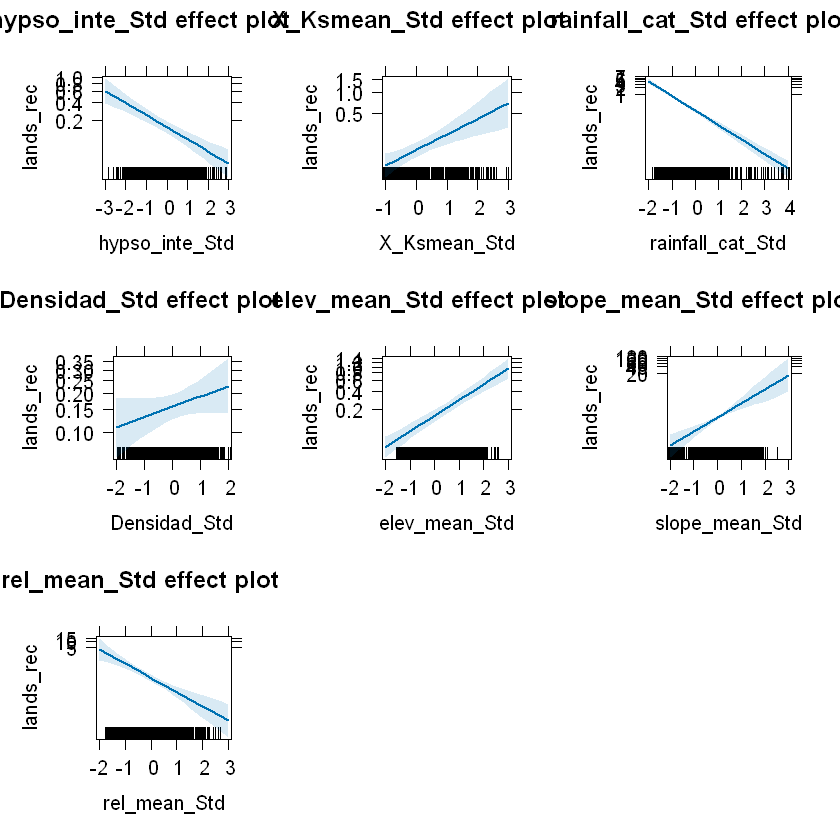

In [40]:
plot(allEffects(glm))

## HGLM

### Random intercept model

In [43]:
hglm_m1rec <- glmer(formula = lands_rec ~ 1 + (1|kmeans),
                 family = poisson,
                 data=df)
summary(hglm_m1rec)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: lands_rec ~ 1 + (1 | kmeans)
   Data: df

     AIC      BIC   logLik deviance df.resid 
  3293.5   3302.5  -1644.7   3289.5      650 

Scaled residuals: 
   Min     1Q Median     3Q    Max 
-1.279 -1.151 -0.553 -0.460 62.849 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.8156   0.9031  
Number of obs: 652, groups:  kmeans, 4

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -0.4981     0.4555  -1.093    0.274

#### Full model

In [49]:
hglm_m2rec <- glmer(formula = lands_rec ~ hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std + Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std + (1|kmeans),
               family = poisson,
               data = df)
summary(hglm_m2rec)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: lands_rec ~ hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std +  
    Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std +  
    (1 | kmeans)
   Data: df

     AIC      BIC   logLik deviance df.resid 
  2252.5   2292.8  -1117.2   2234.5      643 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0846 -0.6140 -0.2823 -0.1397 31.5599 

Random effects:
 Groups Name        Variance Std.Dev.
 kmeans (Intercept) 0.4559   0.6752  
Number of obs: 652, groups:  kmeans, 4

Fixed effects:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)      -2.06397    0.35963  -5.739 9.52e-09 ***
hypso_inte_Std   -0.25265    0.10504  -2.405   0.0162 *  
X_Ksmean_Std      0.62788    0.13671   4.593 4.37e-06 ***
rainfall_cat_Std -1.63832    0.09757 -16.790  < 2e-16 ***
Densidad_Std      0.01298    0.11743   0.111   0.9120    
elev_mean_Std    

#### Full model with random effects

##### ICC
We can also run an ICC (AKA Intraclass Correlation Coefficient) to see the correlation of observations within groups (i.e., relationship satisfaction within each Time point in my case). The ICC index can range from 0 to 1, with more values indicate higher homogeneity within groups (Gelman & Hill, 2007).

You can see that my ICC value is approximately .01, indicating that the relationship satisfaction of participants nested within a point of Time is quite different from each other.

In [54]:
hglm_m3rec <- glmer(formula = lands_rec ~ hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std + Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std + (1 + hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std + Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std |kmeans),
               family = poisson,
               data = df)
summary(hglm_m3rec)

Warning message in commonArgs(par, fn, control, environment()):
"maxfun < 10 * length(par)^2 is not recommended."
Warning message in optwrap(optimizer, devfun, start, rho$lower, control = control, :
"convergence code 1 from bobyqa: bobyqa -- maximum number of function evaluations exceeded"
Warning message in (function (fn, par, lower = rep.int(-Inf, n), upper = rep.int(Inf, :
"failure to converge in 10000 evaluations"
Warning message in optwrap(optimizer, devfun, start, rho$lower, control = control, :
"convergence code 4 from Nelder_Mead: failure to converge in 10000 evaluations"
boundary (singular) fit: see help('isSingular')



Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: lands_rec ~ hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std +  
    Densidad_Std + elev_mean_Std + slope_mean_Std + rel_mean_Std +  
    (1 + hypso_inte_Std + X_Ksmean_Std + rainfall_cat_Std + Densidad_Std +  
        elev_mean_Std + slope_mean_Std + rel_mean_Std | kmeans)
   Data: df

     AIC      BIC   logLik deviance df.resid 
  2099.8   2296.9  -1005.9   2011.8      608 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.9409 -0.5462 -0.2373 -0.0747 30.8238 

Random effects:
 Groups Name             Variance Std.Dev. Corr                               
 kmeans (Intercept)       1.54057 1.2412                                      
        hypso_inte_Std    1.69242 1.3009   -0.51                              
        X_Ksmean_Std      1.80202 1.3424    0.51 -0.97                        
        rainfall_cat_Std  0.51503 0.7177    0.79 -0.34  

In [67]:
performance::icc(hglm_m3rec)

Warning message in commonArgs(par, fn, control, environment()):
"maxfun < 10 * length(par)^2 is not recommended."
Warning message in optwrap(optimizer, devfun, start, rho$lower, control = control, :
"convergence code 1 from bobyqa: bobyqa -- maximum number of function evaluations exceeded"
Warning message in (function (fn, par, lower = rep.int(-Inf, n), upper = rep.int(Inf, :
"failure to converge in 10000 evaluations"
Warning message in optwrap(optimizer, devfun, start, rho$lower, control = control, :
"convergence code 4 from Nelder_Mead: failure to converge in 10000 evaluations"
boundary (singular) fit: see help('isSingular')

Warning message:
"mu of 0.4 is too close to zero, estimate of random effect variances may
  be unreliable."


ICC_adjusted,ICC_conditional,ICC_unadjusted
<dbl>,<dbl>,<dbl>
0.5140685,0.2471045,0.2471045


### BHGLM

#### Intercept only model for hc

In [ ]:
bhglm_ihc <- brm(land ~ 1 + (1 | hc),
                 family = poisson,
                 data   = X,
                 warmup = 1000,
                 iter   = 3000,
                 chains = 2,
                 init  = "random",
                 cores  = 2)

summary(bhglm_ihc)

#### Full model for cat & hc & no prior

In [ ]:
bhglm_f <- brm(lands_rec ~ 1 + hc + cuenca + hypso_inte + (1 + cuenca + hypso_inte | hc),
                 family = poisson,
                 data   = X,
                 warmup = 1000,
                 iter   = 3000,
                 chains = 2,
                 init  = "random",
                 cores  = 2)

summary(bhglm_f)

Compiling Stan program...

Start sampling

Warning message:
"There were 225 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them."
Warning message:
"There were 9 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded"
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"
Warning message:
"There were 225 divergent transitions after warmup. Increasing adapt_delta above 0.8 may help. See http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup"


 Family: poisson 
  Links: mu = log 
Formula: landslides ~ 1 + hc + cuenca + hypso_inte + (1 + cuenca + hypso_inte | hc) 
   Data: X (Number of observations: 652) 
  Draws: 2 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Group-Level Effects: 
~hc (Number of levels: 4) 
                                   Estimate Est.Error l-95% CI u-95% CI Rhat
sd(Intercept)                          2.09      1.86     0.06     6.83 1.01
sd(cuencaCauca)                        1.61      0.84     0.65     3.77 1.00
sd(cuencaMagdalena)                    1.31      1.04     0.18     4.02 1.00
sd(cuencaSanJuan)                      3.66      2.46     1.00     9.94 1.00
sd(cuencaSinu)                         3.44      2.52     0.50     9.65 1.00
sd(hypso_inte)                         3.11      1.74     0.52     7.16 1.00
cor(Intercept,cuencaCauca)            -0.01      0.38    -0.72     0.71 1.00
cor(Intercept,cuencaMagdalena)        -0.01      0.38    -0.71 

#### Full model for cat & hc & with prior

In [ ]:
prior1 <- c(set_prior("normal(0,1)", class = "b", coef = "hypso_inte"))

bhglm_fhc <- brm(lands_rec ~ 0 + Intercept + hc + cuenca + hypso_inte + (1 + cuenca + hypso_inte | hc),
                 family = poisson,
                 data   = X,
                 warmup = 1000,
                 iter   = 3000,
                 prior = prior1,
                 chains = 2,
                 init  = "random",
                 cores  = 2)

summary(bhglm_fhc)

Compiling Stan program...

Start sampling

Warning message:
"There were 176 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them."
Warning message:
"There were 7 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded"
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"
Warning message:
"There were 176 divergent transitions after warmup. Increasing adapt_delta above 0.8 may help. See http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup"


 Family: poisson 
  Links: mu = log 
Formula: landslides ~ 0 + Intercept + hc + cuenca + hypso_inte + (1 + cuenca + hypso_inte | hc) 
   Data: X (Number of observations: 652) 
  Draws: 2 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Group-Level Effects: 
~hc (Number of levels: 4) 
                                   Estimate Est.Error l-95% CI u-95% CI Rhat
sd(Intercept)                          2.27      1.87     0.11     6.96 1.00
sd(cuencaCauca)                        1.61      0.87     0.65     3.91 1.00
sd(cuencaMagdalena)                    1.33      1.09     0.20     4.22 1.00
sd(cuencaSanJuan)                      3.74      2.64     0.94    10.25 1.00
sd(cuencaSinu)                         3.44      2.55     0.51     9.68 1.00
sd(hypso_inte)                         2.90      1.50     0.54     6.47 1.00
cor(Intercept,cuencaCauca)            -0.01      0.38    -0.72     0.70 1.00
cor(Intercept,cuencaMagdalena)         0.01      0.

### BHGAM

In [ ]:
bhgam <- brm(lands_rec ~ 0 + Intercept + hc + cuenca + s(hypso_inte) + (1 + cuenca + hypso_inte | hc),
                 family = poisson,
                 data   = X,
                 warmup = 1000,
                 iter   = 3000,
                 cores  = 2,
                 thin = 10,
                 control = list(adapt_delta = 0.99))

summary(bhgam)

Compiling Stan program...

Start sampling

Warning message:
"There were 2 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them."
Warning message:
"There were 798 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded"
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"
Warning message:
"Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#bulk-ess"
Warning message:
"Tail Effective Samples Size (ESS) is too low, indicating posterior variances and tail quantiles may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#tail-ess"
Warning message:


 Family: poisson 
  Links: mu = log 
Formula: landslides ~ 0 + Intercept + hc + cuenca + s(hypso_inte) + (1 + cuenca + hypso_inte | hc) 
   Data: X (Number of observations: 652) 
  Draws: 4 chains, each with iter = 3000; warmup = 1000; thin = 10;
         total post-warmup draws = 800

Smooth Terms: 
                   Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sds(shypso_inte_1)     4.04      1.96     1.39     8.57 1.00      575      360

Group-Level Effects: 
~hc (Number of levels: 4) 
                                   Estimate Est.Error l-95% CI u-95% CI Rhat
sd(Intercept)                          2.60      2.87     0.07    10.16 1.01
sd(cuencaCauca)                        1.66      0.95     0.65     4.19 1.00
sd(cuencaMagdalena)                    1.33      1.05     0.13     4.18 1.00
sd(cuencaSanJuan)                      3.86      2.59     1.03     9.96 1.00
sd(cuencaSinu)                         3.49      2.36     0.63     9.88 1.01
sd(hypso_inte)              

Warning message:
"Method 'marginal_smooths' is deprecated. Please use 'conditional_smooths' instead."


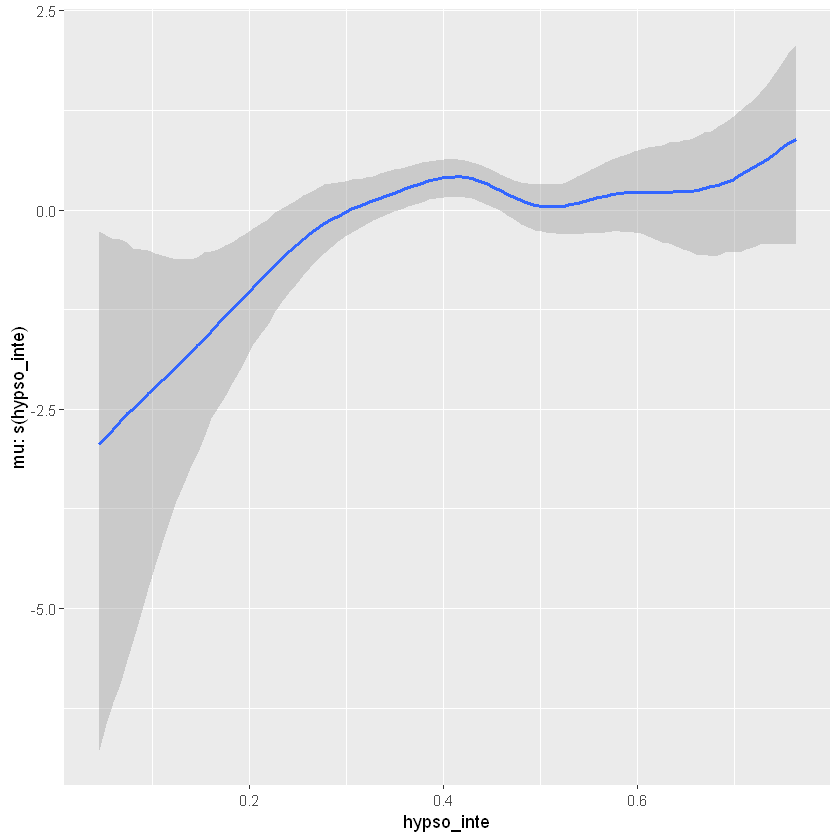

In [ ]:
msms <- marginal_smooths(bhgam)
plot(msms)